<a href="https://www.kaggle.com/code/lalit7881/online-shopper-purchase-data?scriptVersionId=304159710" target="_blank"><img align="left" alt="Kaggle" title="Open in Kaggle" src="https://kaggle.com/static/images/open-in-kaggle.svg"></a>

In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/datasets/thuandao/online-shoppers-purchasing-dataset/online_shoppers.csv


## Import libraries

In [2]:
import seaborn as sns
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings("ignore")

## Loading dataset

In [3]:
df = pd.read_csv("/kaggle/input/datasets/thuandao/online-shoppers-purchasing-dataset/online_shoppers.csv")

## First Rows

In [4]:
df.head()

,Administrative,Administrative_Duration,Informational,Informational_Duration,ProductRelated,ProductRelated_Duration,BounceRates,ExitRates,PageValues,SpecialDay,OperatingSystems,Browser,Region,TrafficType,Month,VisitorType,Weekend,Revenue
0,0,0.000000,0,0.000000,0,0.000000,0.016765,0.085003,3.191731,0.000000,2,1,1,1,Nov,Returning_Visitor,False,False
1,3,140.433150,0,121.793138,55,2333.187358,0.000000,0.034682,0.000000,0.221186,3,3,3,5,Dec,Returning_Visitor,False,False
2,2,169.063012,1,72.697027,23,1448.426947,0.068493,0.075369,0.000000,0.000000,2,2,2,12,Sep,Returning_Visitor,False,False
3,4,129.698301,1,118.581521,53,1238.760755,0.024336,0.049339,14.476824,0.124415,1,1,4,8,May,New_Visitor,False,False
4,2,214.526081,2,235.043689,37,297.590433,0.001517,0.018661,37.270547,0.071883,3,4,5,9,Nov,Returning_Visitor,False,True


## Display Last Rows

In [5]:
df.tail()

,Administrative,Administrative_Duration,Informational,Informational_Duration,ProductRelated,ProductRelated_Duration,BounceRates,ExitRates,PageValues,SpecialDay,OperatingSystems,Browser,Region,TrafficType,Month,VisitorType,Weekend,Revenue
999994,5,145.040629,0,116.976540,111,3390.402343,0.000000,0.000000,0.000000,0.000000,2,1,7,1,May,New_Visitor,False,False
999995,0,0.000000,1,82.310616,0,0.000000,0.128995,0.183235,0.000000,0.216012,1,2,1,7,Mar,Returning_Visitor,False,False
999996,2,68.850234,0,0.000000,13,0.000000,0.072351,0.085056,8.755833,0.000000,2,4,4,1,Mar,Returning_Visitor,False,False
999997,5,0.000000,0,97.971941,35,1696.862699,0.024662,0.051551,11.351870,0.198211,2,3,1,7,May,Returning_Visitor,False,True
999998,6,371.253958,1,205.425700,16,1031.946111,0.059128,0.044228,0.000000,0.000000,4,2,2,3,June,Returning_Visitor,False,False


## Dataset Shape (Rows, Columns)

In [6]:
df.shape

(999999, 18)

## Column Names

In [7]:
df.columns

Index(['Administrative', 'Administrative_Duration', 'Informational',
       'Informational_Duration', 'ProductRelated', 'ProductRelated_Duration',
       'BounceRates', 'ExitRates', 'PageValues', 'SpecialDay',
       'OperatingSystems', 'Browser', 'Region', 'TrafficType', 'Month',
       'VisitorType', 'Weekend', 'Revenue'],
      dtype='object')

## Dataset Information

In [8]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 999999 entries, 0 to 999998
Data columns (total 18 columns):
 #   Column                   Non-Null Count   Dtype  
---  ------                   --------------   -----  
 0   Administrative           999999 non-null  int64  
 1   Administrative_Duration  999999 non-null  float64
 2   Informational            999999 non-null  int64  
 3   Informational_Duration   999999 non-null  float64
 4   ProductRelated           999999 non-null  int64  
 5   ProductRelated_Duration  999999 non-null  float64
 6   BounceRates              999999 non-null  float64
 7   ExitRates                999999 non-null  float64
 8   PageValues               999999 non-null  float64
 9   SpecialDay               999999 non-null  float64
 10  OperatingSystems         999999 non-null  int64  
 11  Browser                  999999 non-null  int64  
 12  Region                   999999 non-null  int64  
 13  TrafficType              999999 non-null  int64  
 14  Mont

## Statistical Summary

In [9]:
df.describe()

,Administrative,Administrative_Duration,Informational,Informational_Duration,ProductRelated,ProductRelated_Duration,BounceRates,ExitRates,PageValues,SpecialDay,OperatingSystems,Browser,Region,TrafficType
count,999999.000000,999999.000000,999999.000000,999999.000000,999999.000000,999999.000000,999999.000000,999999.000000,999999.000000,999999.000000,999999.000000,999999.000000,999999.000000,999999.000000
mean,2.780929,117.859962,0.782443,74.695244,37.609186,1496.799697,0.031455,0.047372,8.854572,0.112650,2.164484,2.562506,3.386572,4.584336
std,2.679913,130.018648,0.953054,94.262121,36.208370,1507.551284,0.036899,0.042088,15.863277,0.138431,0.883892,1.440884,2.035283,3.291207
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,1.000000,1.000000,1.000000
25%,0.000000,0.000000,0.000000,0.000000,2.000000,0.000000,0.000000,0.011138,0.000000,0.000000,2.000000,1.000000,2.000000,1.000000
50%,2.000000,79.661895,0.000000,33.858389,31.000000,1170.143584,0.017177,0.038529,3.041656,0.057565,2.000000,2.000000,3.000000,4.000000
75%,5.000000,198.785702,1.000000,127.585937,60.000000,2449.121147,0.053225,0.074927,10.601374,0.190380,3.000000,4.000000,5.000000,7.000000
max,20.000000,1179.088209,7.000000,875.337147,299.000000,12125.673897,0.200000,0.200000,191.907635,1.000000,6.000000,11.000000,9.000000,20.000000


## Check Missing Values

In [10]:
df.isnull().sum()

Administrative             0
Administrative_Duration    0
Informational              0
Informational_Duration     0
ProductRelated             0
ProductRelated_Duration    0
BounceRates                0
ExitRates                  0
PageValues                 0
SpecialDay                 0
OperatingSystems           0
Browser                    0
Region                     0
TrafficType                0
Month                      0
VisitorType                0
Weekend                    0
Revenue                    0
dtype: int64

## Unique Values in Each Column

In [11]:
df.nunique()

Administrative                 21
Administrative_Duration    675301
Informational                   8
Informational_Duration     596528
ProductRelated                269
ProductRelated_Duration    734166
BounceRates                682759
ExitRates                  830034
PageValues                 616313
SpecialDay                 619663
OperatingSystems                6
Browser                        11
Region                          9
TrafficType                    20
Month                          10
VisitorType                     3
Weekend                         2
Revenue                         2
dtype: int64

## EDA

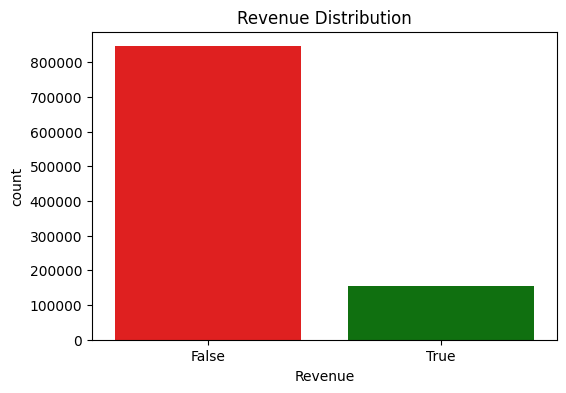

In [12]:
plt.figure(figsize=(6,4))
sns.countplot(x='Revenue', data=df, palette=['red','green'])
plt.title("Revenue Distribution")
plt.show()

## Visitor Type Distribution

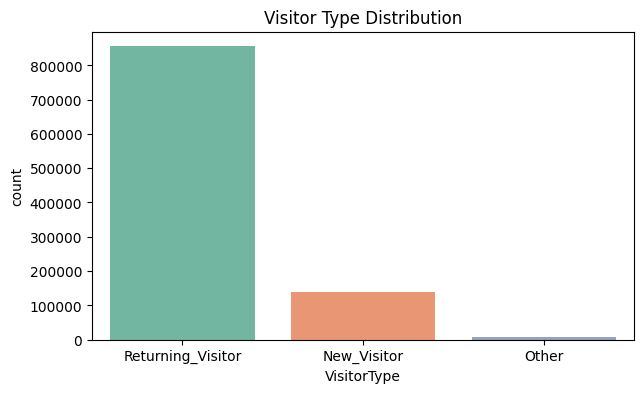

In [13]:
plt.figure(figsize=(7,4))
sns.countplot(x='VisitorType', data=df, palette='Set2')
plt.title("Visitor Type Distribution")
plt.show()

## Month-wise Visitors

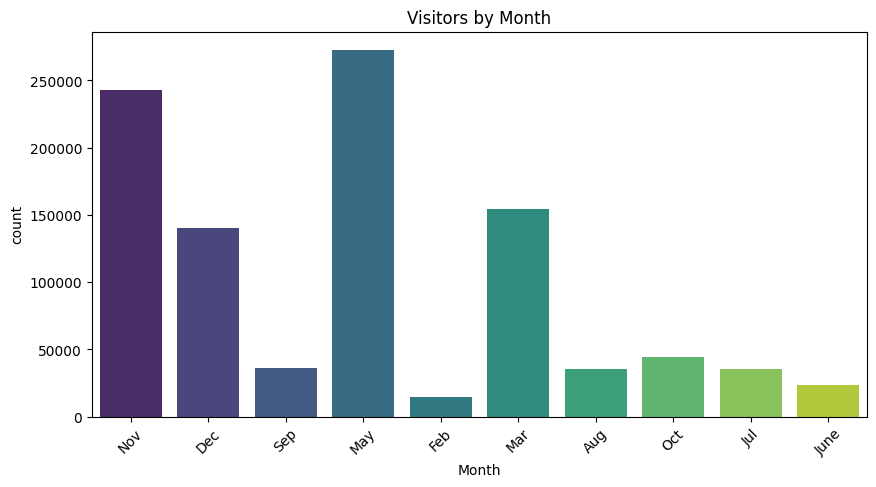

In [14]:
plt.figure(figsize=(10,5))
sns.countplot(x='Month', data=df, palette='viridis')
plt.title("Visitors by Month")
plt.xticks(rotation=45)
plt.show()

## Weekend vs Revenue

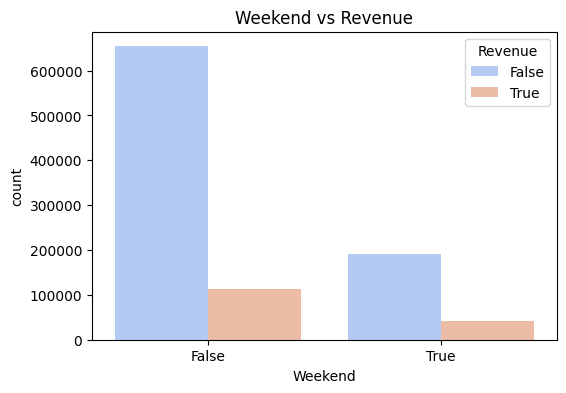

In [15]:
plt.figure(figsize=(6,4))
sns.countplot(x='Weekend', hue='Revenue', data=df, palette='coolwarm')
plt.title("Weekend vs Revenue")
plt.show()

## Bounce Rate Distribution

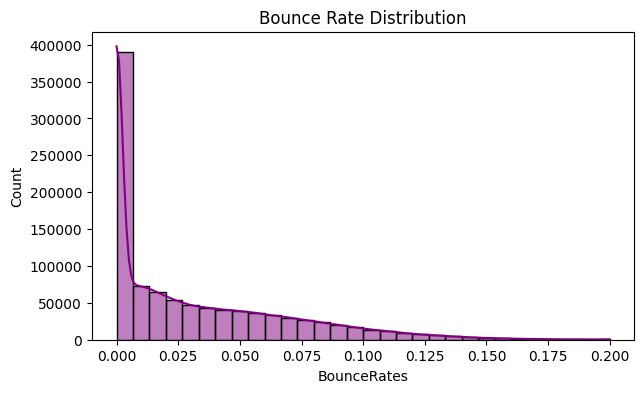

In [16]:
plt.figure(figsize=(7,4))
sns.histplot(df['BounceRates'], bins=30, color='purple', kde=True)
plt.title("Bounce Rate Distribution")
plt.show()

## Exit Rate Distribution

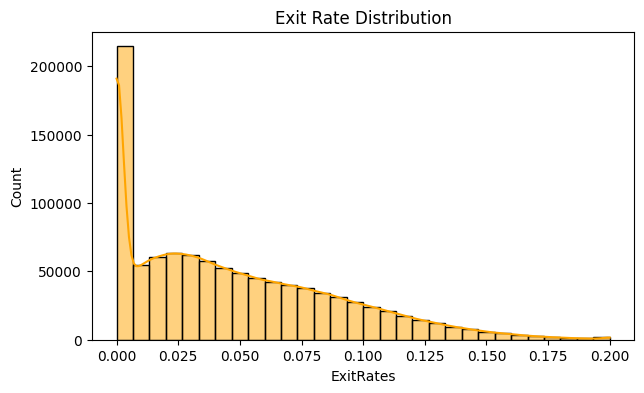

In [17]:
plt.figure(figsize=(7,4))
sns.histplot(df['ExitRates'], bins=30, color='orange', kde=True)
plt.title("Exit Rate Distribution")
plt.show()

## Page Values Distribution

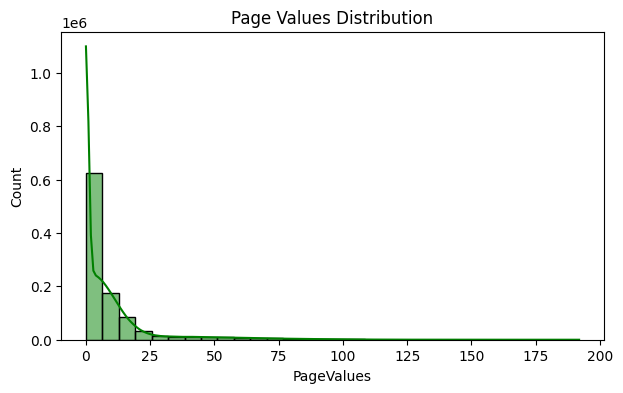

In [18]:
plt.figure(figsize=(7,4))
sns.histplot(df['PageValues'], bins=30, color='green', kde=True)
plt.title("Page Values Distribution")
plt.show()

## Product Related Pages vs Revenue

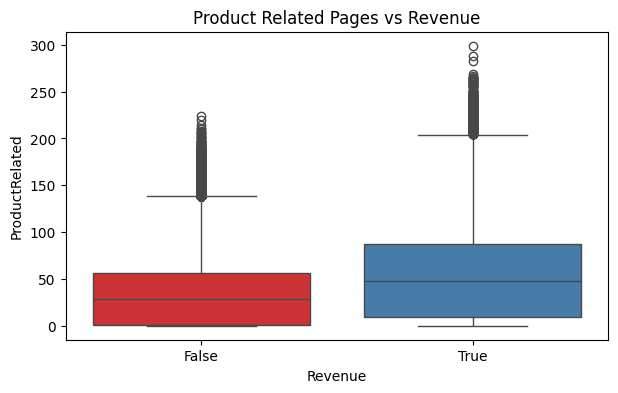

In [19]:
plt.figure(figsize=(7,4))
sns.boxplot(x='Revenue', y='ProductRelated', data=df, palette='Set1')
plt.title("Product Related Pages vs Revenue")
plt.show()

## Administrative Pages vs Revenue

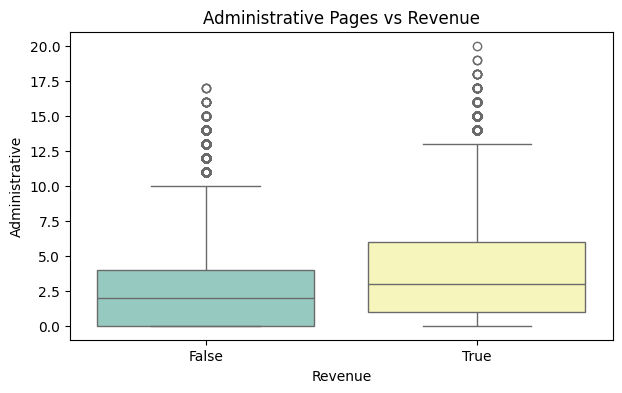

In [20]:
plt.figure(figsize=(7,4))
sns.boxplot(x='Revenue', y='Administrative', data=df, palette='Set3')
plt.title("Administrative Pages vs Revenue")
plt.show()

## Informational Pages vs Revenue

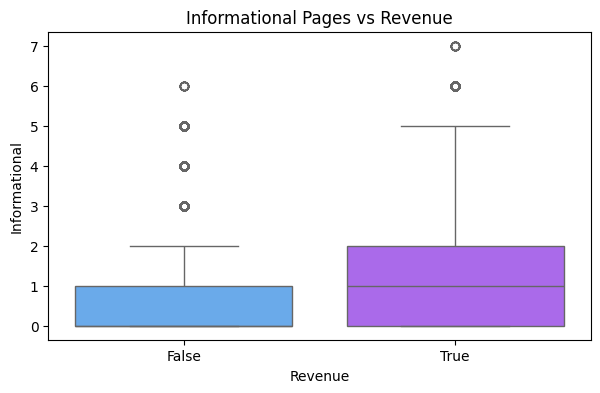

In [21]:
plt.figure(figsize=(7,4))
sns.boxplot(x='Revenue', y='Informational', data=df, palette='cool')
plt.title("Informational Pages vs Revenue")
plt.show()

## Traffic Type Distribution

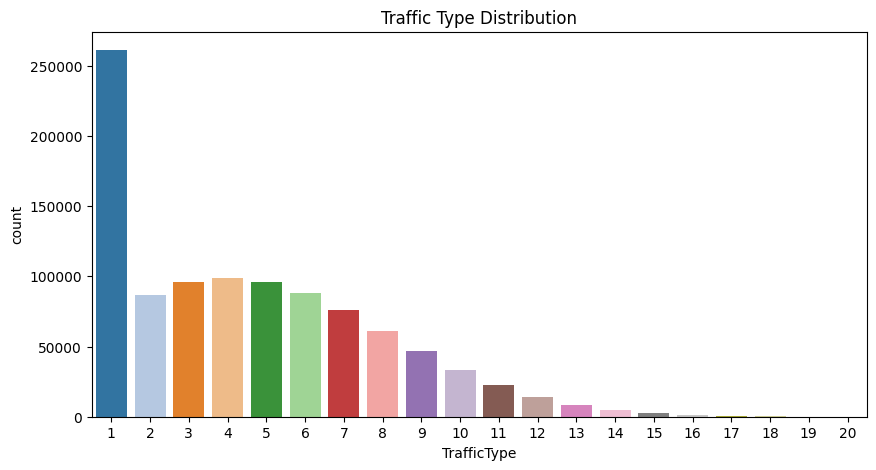

In [22]:
plt.figure(figsize=(10,5))
sns.countplot(x='TrafficType', data=df, palette='tab20')
plt.title("Traffic Type Distribution")
plt.show()

## Correlation Heatmap

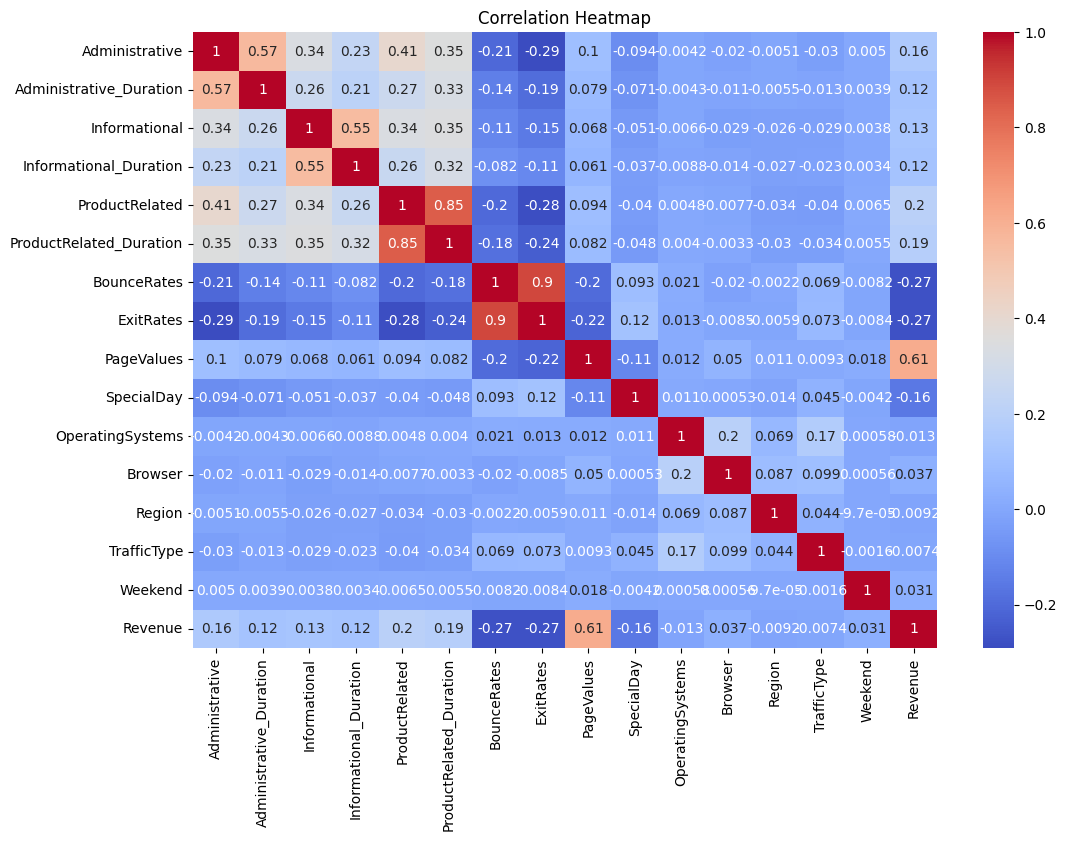

In [23]:
plt.figure(figsize=(12,8))
sns.heatmap(df.corr(numeric_only=True), annot=True, cmap='coolwarm')
plt.title("Correlation Heatmap")
plt.show()

## PageValues vs Revenue Scatter

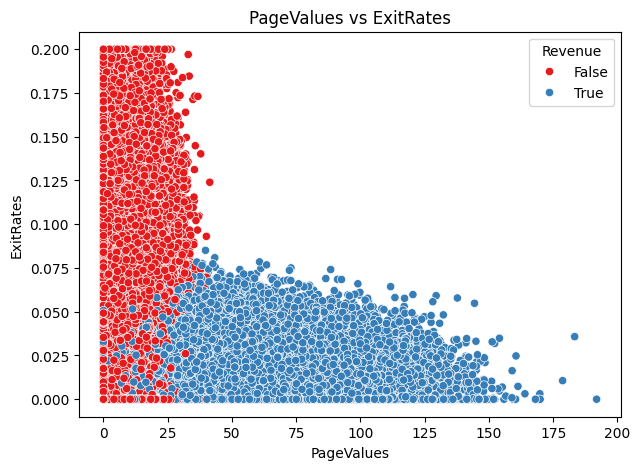

In [24]:
plt.figure(figsize=(7,5))
sns.scatterplot(x='PageValues', y='ExitRates', hue='Revenue', data=df, palette='Set1')
plt.title("PageValues vs ExitRates")
plt.show()

## ProductRelated Duration Distribution

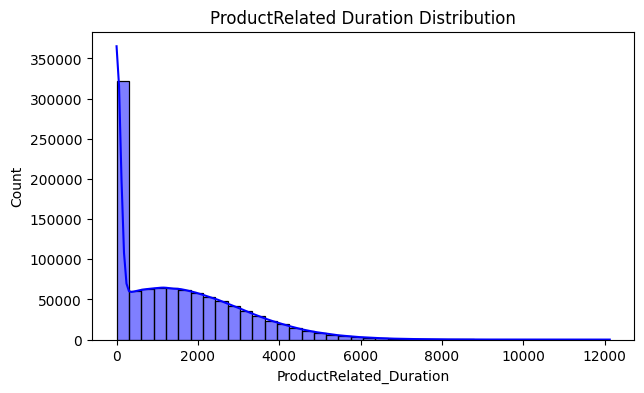

In [25]:
plt.figure(figsize=(7,4))
sns.histplot(df['ProductRelated_Duration'], bins=40, color='blue', kde=True)
plt.title("ProductRelated Duration Distribution")
plt.show()

## Feature engineering

In [26]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report, roc_curve, auc

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.svm import SVC

## Label Encoding

In [27]:
le = LabelEncoder()

categorical_cols = ['Month','VisitorType','Weekend','Revenue']

for col in categorical_cols:
    df[col] = le.fit_transform(df[col])

df.head()

,Administrative,Administrative_Duration,Informational,Informational_Duration,ProductRelated,ProductRelated_Duration,BounceRates,ExitRates,PageValues,SpecialDay,OperatingSystems,Browser,Region,TrafficType,Month,VisitorType,Weekend,Revenue
0,0,0.000000,0,0.000000,0,0.000000,0.016765,0.085003,3.191731,0.000000,2,1,1,1,7,2,0,0
1,3,140.433150,0,121.793138,55,2333.187358,0.000000,0.034682,0.000000,0.221186,3,3,3,5,1,2,0,0
2,2,169.063012,1,72.697027,23,1448.426947,0.068493,0.075369,0.000000,0.000000,2,2,2,12,9,2,0,0
3,4,129.698301,1,118.581521,53,1238.760755,0.024336,0.049339,14.476824,0.124415,1,1,4,8,6,0,0,0
4,2,214.526081,2,235.043689,37,297.590433,0.001517,0.018661,37.270547,0.071883,3,4,5,9,7,2,0,1


## Define Features and Target

In [28]:
X = df.drop("Revenue", axis=1)
y = df["Revenue"]

## Train Test Split

In [29]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

## Define Models

In [30]:
models = {
    "Logistic Regression": LogisticRegression(max_iter=500),
    "Decision Tree": DecisionTreeClassifier(),
    "Random Forest": RandomForestClassifier(),
}

## Train Models and Show Accuracy

In [31]:
for name, model in models.items():
    
    model.fit(X_train, y_train)
    
    y_pred = model.predict(X_test)
    
    acc = accuracy_score(y_test, y_pred)
    
    print("Model:", name)
    print("Accuracy:", acc)
    print(classification_report(y_test, y_pred))
    print("-"*50)

Model: Logistic Regression
Accuracy: 0.9143
              precision    recall  f1-score   support

           0       0.92      0.98      0.95    169192
           1       0.86      0.53      0.66     30808

    accuracy                           0.91    200000
   macro avg       0.89      0.76      0.80    200000
weighted avg       0.91      0.91      0.91    200000

--------------------------------------------------
Model: Decision Tree
Accuracy: 0.909415
              precision    recall  f1-score   support

           0       0.95      0.94      0.95    169192
           1       0.70      0.72      0.71     30808

    accuracy                           0.91    200000
   macro avg       0.82      0.83      0.83    200000
weighted avg       0.91      0.91      0.91    200000

--------------------------------------------------
Model: Random Forest
Accuracy: 0.942305
              precision    recall  f1-score   support

           0       0.95      0.99      0.97    169192
           

## Confusion Matrix Visualization

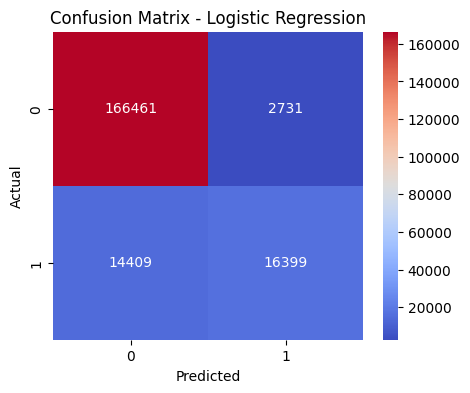

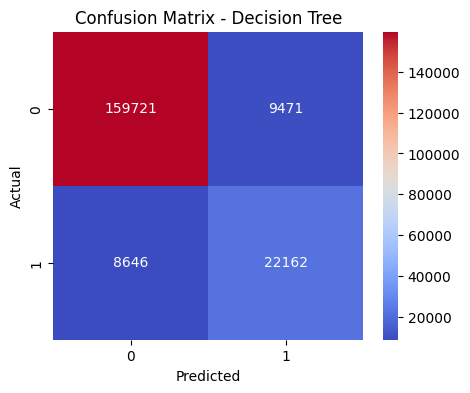

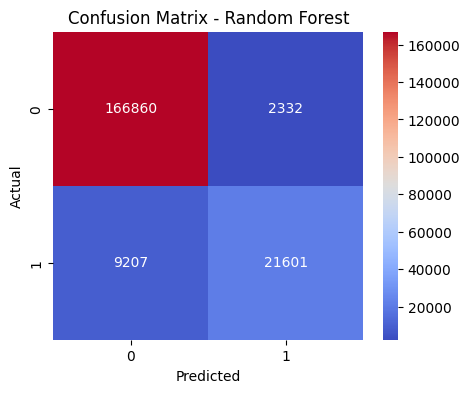

In [32]:
for name, model in models.items():
    
    y_pred = model.predict(X_test)
    
    cm = confusion_matrix(y_test, y_pred)
    
    plt.figure(figsize=(5,4))
    sns.heatmap(cm, annot=True, fmt="d", cmap="coolwarm")
    plt.title(f"Confusion Matrix - {name}")
    plt.xlabel("Predicted")
    plt.ylabel("Actual")
    plt.show()

## ROC Curve for All Models

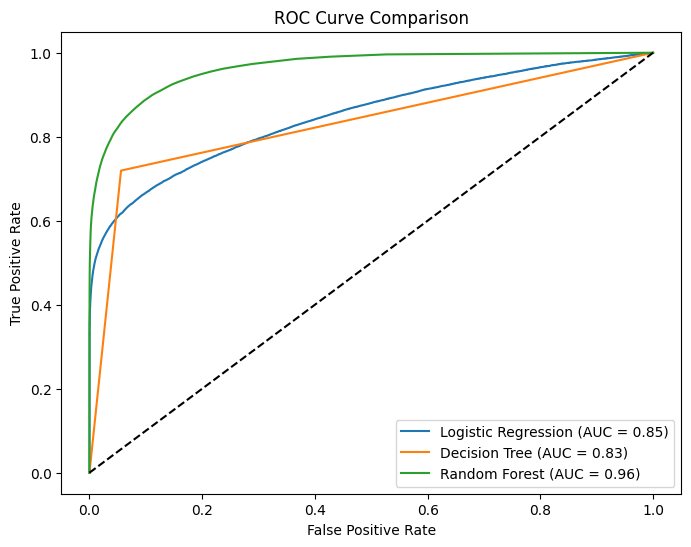

In [33]:
plt.figure(figsize=(8,6))

for name, model in models.items():
    
    y_prob = model.predict_proba(X_test)[:,1]
    
    fpr, tpr, _ = roc_curve(y_test, y_prob)
    
    roc_auc = auc(fpr, tpr)
    
    plt.plot(fpr, tpr, label=f"{name} (AUC = {roc_auc:.2f})")

plt.plot([0,1],[0,1],'k--')

plt.title("ROC Curve Comparison")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.legend()
plt.show()

## Model Accuracy Comparison Plot

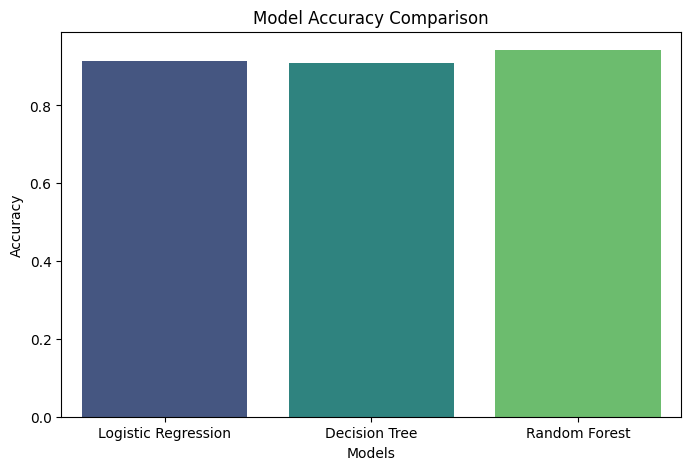

In [34]:
accuracy_scores = []

for name, model in models.items():
    
    y_pred = model.predict(X_test)
    
    acc = accuracy_score(y_test, y_pred)
    
    accuracy_scores.append(acc)

plt.figure(figsize=(8,5))
sns.barplot(x=list(models.keys()), y=accuracy_scores, palette="viridis")

plt.title("Model Accuracy Comparison")
plt.ylabel("Accuracy")
plt.xlabel("Models")

plt.show()

## Thank you..pls upvote!!!!!!!!